# Outlier Detection and Handling

This notebook covers techniques for identifying and treating outliers in datasets, which is essential to prevent machine learning models from getting biased. Topics covered:
*   Outliers visualization using boxplots
*   Interquartile Range (IQR) method
*   Z-Score method (Standard Deviation analysis)
*   Outlier detection practice on Superstore and Playstore datasets.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Superstore.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
# 4. Numeric vs Category columns
df.select_dtypes(include="number").columns

Index(['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')

In [8]:
df.select_dtypes(exclude="number").columns
# customer_id , order_id, product_id,

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name'],
      dtype='object')

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136


In [11]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])

In [12]:
df["Year"]=df["Order Date"].dt.year
df["Month"]=df["Order Date"].dt.month

In [13]:
df["Postal Code"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9994 entries, 0 to 9993
Series name: Postal Code
Non-Null Count  Dtype
--------------  -----
9994 non-null   int64
dtypes: int64(1)
memory usage: 78.2 KB


# Outliers

In [14]:
S_mean=df['Sales'].mean()
S_std=df['Sales'].std()
print(S_mean,S_std,sep=',')

229.85800083049833,623.2451005086807


In [15]:
P_mean=df['Profit'].mean()
P_std=df['Profit'].std()
print(P_mean,P_std,sep=',')

28.65689630778467,234.2601076909573


In [16]:
def z_score(col):
    df['z_score_Sales']=abs((df[col]-S_mean)/S_std)
z_score('Sales')

In [17]:
def z_score(col):
    df['z_score_Profit']=abs((df[col]-P_mean)/P_std)
z_score('Profit')

In [18]:
df["z_score_Profit"]

0       0.056590
1       0.815013
2       0.092997
3       1.757397
4       0.111587
          ...   
9989    0.104816
9990    0.055595
9991    0.039544
9992    0.065470
9993    0.189068
Name: z_score_Profit, Length: 9994, dtype: float64

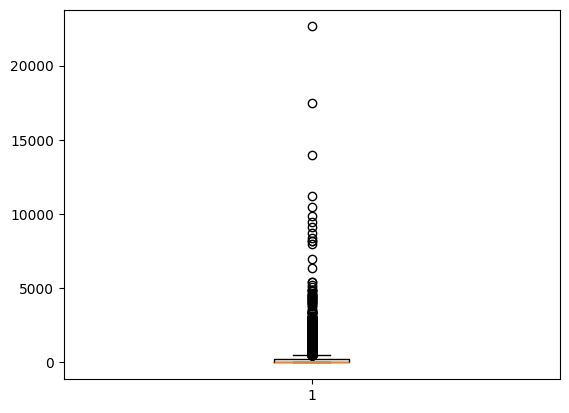

In [19]:
plt.boxplot(df["Sales"])
plt.show()


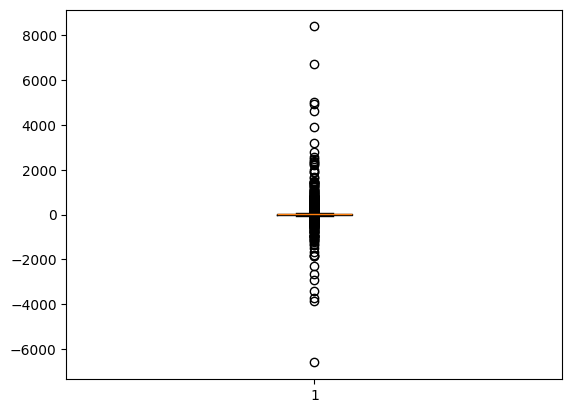

In [20]:
plt.boxplot(df["Profit"])
plt.show()

In [21]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,z_score_Sales,z_score_Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,0.051508,0.056590
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,0.805593,0.815013
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,0.345350,0.092997
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,1.167630,1.757397
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,0.332919,0.111587


In [22]:
df["Customer Name"]

0            Claire Gute
1            Claire Gute
2        Darrin Van Huff
3         Sean O'Donnell
4         Sean O'Donnell
              ...       
9989    Tom Boeckenhauer
9990         Dave Brooks
9991         Dave Brooks
9992         Dave Brooks
9993        Chris Cortes
Name: Customer Name, Length: 9994, dtype: object

In [23]:
df.drop("Customer ID",axis=1,inplace=True)
df.drop("Row ID",axis=1,inplace=True)

In [24]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,Country,City,State,Postal Code,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,z_score_Sales,z_score_Profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,0.051508,0.056590
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,0.805593,0.815013
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,0.345350,0.092997
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,1.167630,1.757397
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,0.332919,0.111587


In [25]:
df.to_csv("CLeaned_superstore.csv")

In [26]:
l1=[1,2,3]

for i in l1:
    l1+=l1[i]*n
print(l1)


NameError: name 'n' is not defined

In [ ]:
n=int(input("enter  n:"))
print(n)
res=[n*2 for num in l1]
print(res)

ValueError: invalid literal for int() with base 10: ''

---
## 📈 Outlier Detection using Z-Score (Rating Column)

*(This section is consolidated from `rating_outlier.ipynb`)*

Using standard deviation thresholding (Z-Score > 3) to locate rating outliers in the Google Play Store dataset.

In [3]:
df=pd.read_csv("googleplaystore.csv")

In [4]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [5]:
df['Rating']

0        4.1
1        3.9
2        4.7
3        4.5
4        4.3
        ... 
10836    4.5
10837    5.0
10838    NaN
10839    4.5
10840    4.5
Name: Rating, Length: 10841, dtype: float64

In [6]:
df['Rating'].sum()

39279.0

In [7]:
df['Rating'].unique

<bound method Series.unique of 0        4.1
1        3.9
2        4.7
3        4.5
4        4.3
        ... 
10836    4.5
10837    5.0
10838    NaN
10839    4.5
10840    4.5
Name: Rating, Length: 10841, dtype: float64>

In [8]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [9]:
df['Rating'].dtype

dtype('float64')

In [10]:
df.dropna(inplace=True)

In [11]:
df.isna().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [12]:
x_mean=df['Rating'].mean()
x_std=df['Rating'].std()
print(x_mean,x_std,sep=',')

4.191837606837606,0.5152629700664094


In [13]:
def z_score(col):
    df['z-score']=abs((df[col]-x_mean)/x_std)
z_score('Rating')

In [14]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'z-score'],
      dtype='object')

In [15]:
df[df['z-score']>3]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,z-score
477,Calculator,DATING,2.6,57,6.2M,"1,000+",Paid,$6.99,Everyone,Dating,"October 25, 2017",1.1.6,4.0 and up,3.089369
518,Just She - Top Lesbian Dating,DATING,1.9,953,19M,"100,000+",Free,0,Mature 17+,Dating,"July 18, 2018",6.3.7,5.0 and up,4.447899
520,EliteSingles – Dating for Single Professionals,DATING,2.5,5377,19M,"500,000+",Free,0,Mature 17+,Dating,"July 31, 2018",4.8.5,4.0.3 and up,3.283445
527,Sugar Daddy Dating App,DATING,2.5,277,5.7M,"100,000+",Free,0,Mature 17+,Dating,"December 4, 2017",3.0.0,4.1 and up,3.283445
549,EliteSingles – Dating for Single Professionals,DATING,2.5,5377,19M,"500,000+",Free,0,Mature 17+,Dating,"July 31, 2018",4.8.5,4.0.3 and up,3.283445
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10458,Candy simply-Fi,LIFESTYLE,2.1,2390,35M,"100,000+",Free,0,Everyone,Lifestyle,"July 17, 2018",1.8.4.7,4.4 and up,4.059748
10562,FK Atlantas,SPORTS,1.5,2,26M,5+,Free,0,Everyone,Sports,"February 21, 2018",1.0,4.1 and up,5.224202
10578,Check Lottery Tickets - Florida,FAMILY,2.0,27,31M,"5,000+",Free,0,Teen,Entertainment,"October 17, 2017",2.1,4.0.3 and up,4.253823
10591,Lottery Ticket Checker - Florida Results & Lotto,TOOLS,1.0,3,41M,500+,Free,0,Everyone,Tools,"December 12, 2017",1.0,4.2 and up,6.194580


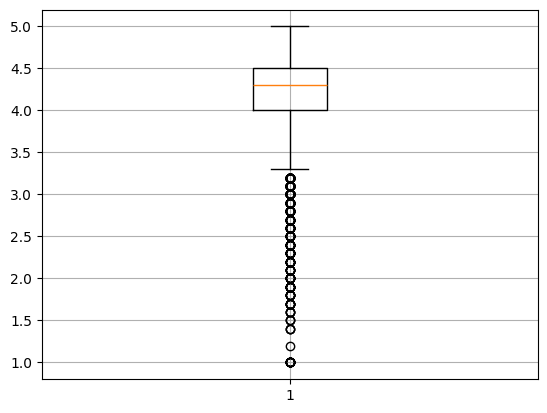

In [16]:
plt.boxplot(df['Rating'])
plt.grid()

In [21]:
df[df['z-score']>3].shape
#df[df['z-score']>3].head()


(175, 14)

In [18]:
(175/df.shape[0])*100

1.8696581196581197

In [19]:
outliers=df[df['z-score']>3]

In [20]:
outliers['Rating'].describe

<bound method NDFrame.describe of 477      2.6
518      1.9
520      2.5
527      2.5
549      2.5
        ... 
10458    2.1
10562    1.5
10578    2.0
10591    1.0
10677    2.5
Name: Rating, Length: 175, dtype: float64>